In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     345   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


In [4]:
image_cut = image[72:172, 0:1890]
image_error_cut = image_error[72:172, 0:1890]

Text(0.5, 0, 'wavelength')

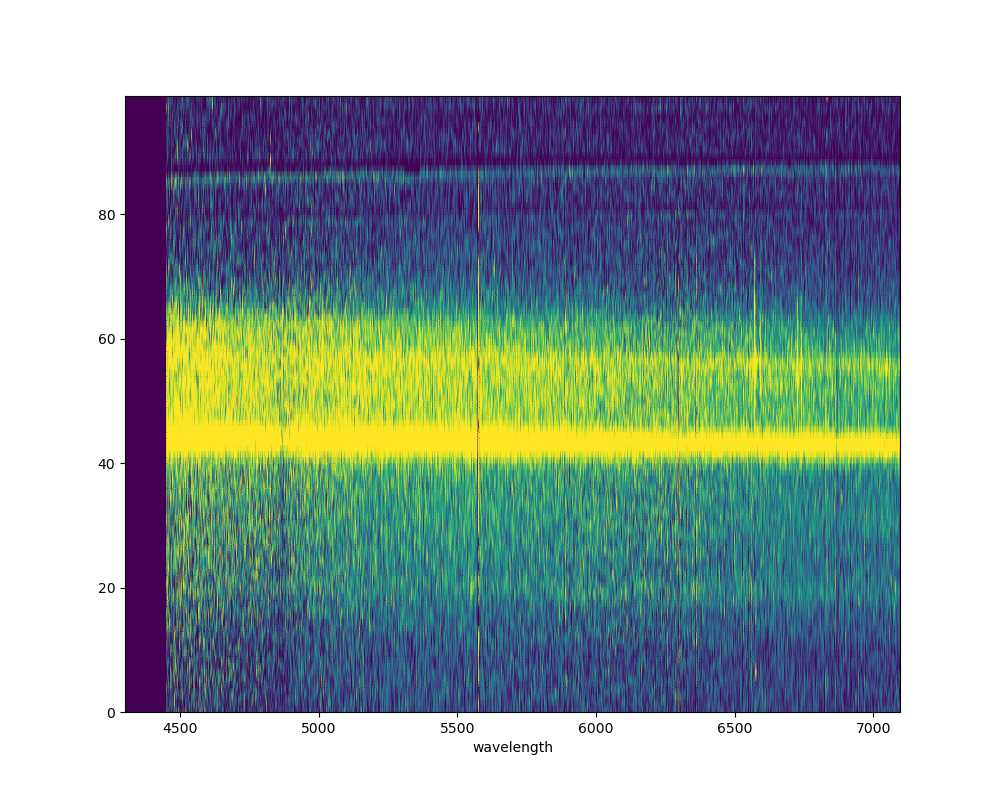

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00189
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/PSF/Real_seeing_UGC7596.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.00975469 1.11579628 1.00705203 0.98920122 1.12349157 1.01319149]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     345   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        44   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

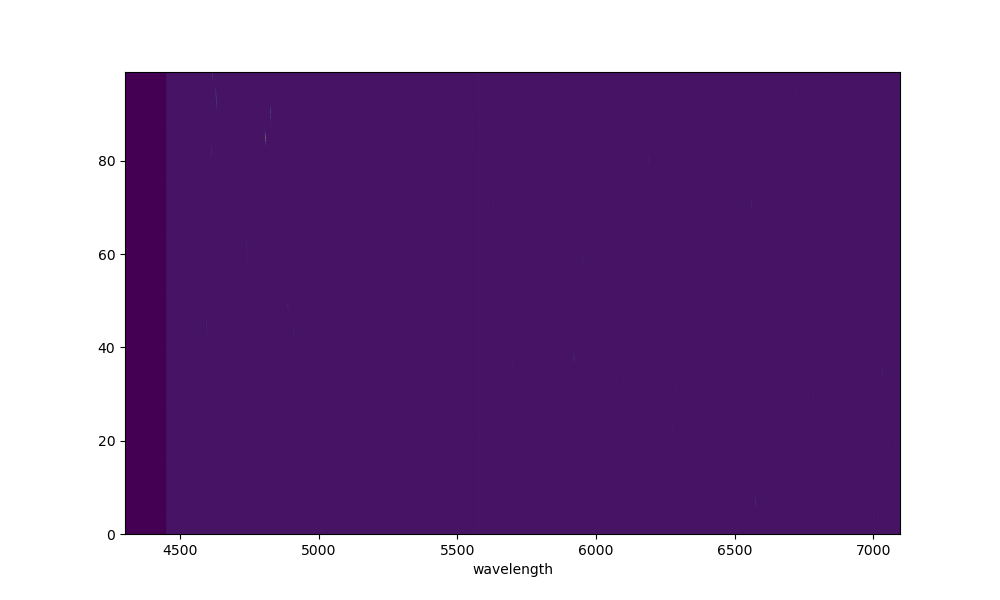

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/UGC-7596_2_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[72:172, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

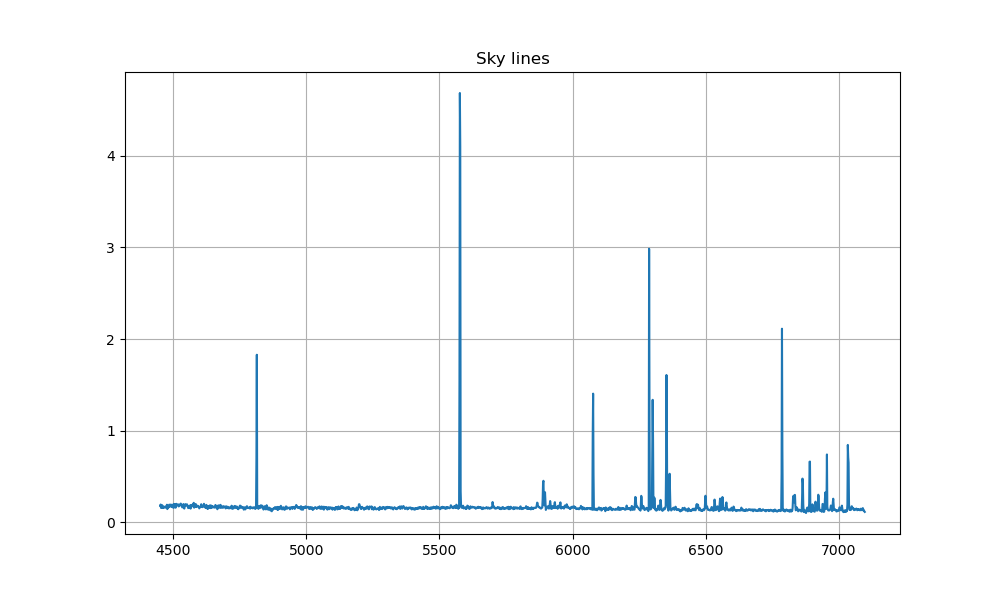

In [8]:
mask_sky = (y > 25)*(y < 35)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

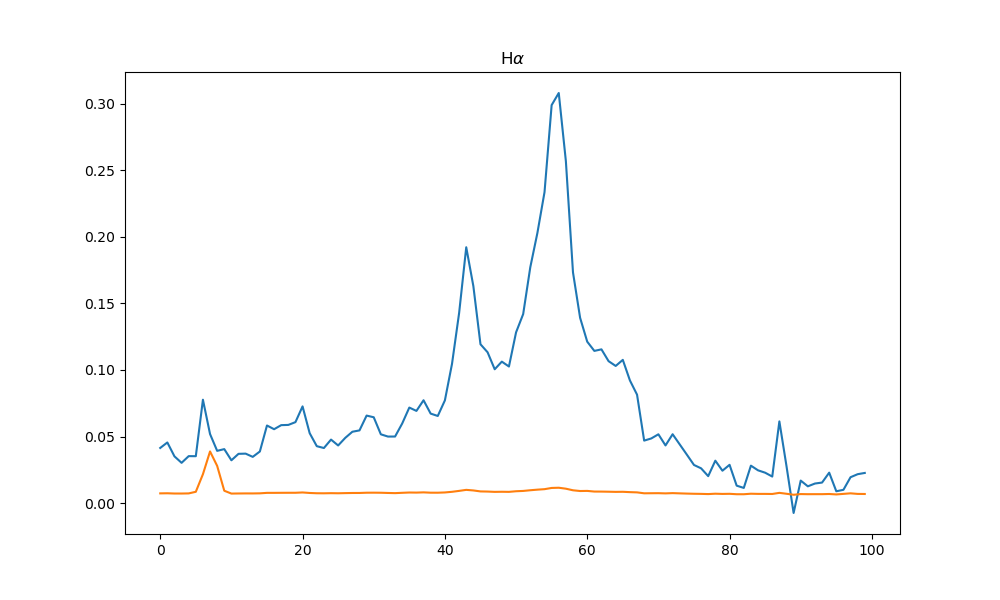

In [9]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/UGC7596/UGC7596_2/FORS2.2022-01-30T07_40_05.209/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [15]:
n_component = 4

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])# +
        #sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 0.35)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 0.35)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA = [

    (0, 20),
    (0, 50),
    (0.1, 10),
    (42, 44),
    
    (0, 20),
    (0, 50),
    (0.1, 10),
    (55, 57),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (62, 64),

    (0, 20),
    (50, 150),
    (0.1, 10),
    (45, 55),
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [11]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 63082.76675422091
differential_evolution step 2: f(x)= 51505.28361254013
differential_evolution step 3: f(x)= 16400.072401828427
differential_evolution step 4: f(x)= 16400.072401828427
differential_evolution step 5: f(x)= 11803.146961414663
differential_evolution step 6: f(x)= 11803.146961414663
differential_evolution step 7: f(x)= 11803.146961414663
differential_evolution step 8: f(x)= 11803.146961414663
differential_evolution step 9: f(x)= 11803.146961414663
differential_evolution step 10: f(x)= 9417.685963116734
differential_evolution step 11: f(x)= 9417.685963116734
differential_evolution step 12: f(x)= 9417.685963116734
differential_evolution step 13: f(x)= 9417.685963116734
differential_evolution step 14: f(x)= 9417.685963116734
differential_evolution step 15: f(x)= 9417.685963116734
differential_evolution step 16: f(x)= 9417.685963116734
differential_evolution step 17: f(x)= 9417.685963116734
differential_evolution step 18: f(x)= 9417.6859631

Sérsic 1: I_e=0.0009, r_e=8.4227, n=5.0425, x_0=43.1055
Sérsic 2: I_e=0.0449, r_e=5.2657, n=1.1966, x_0=55.4765
Sérsic 3: I_e=0.0331, r_e=2.3741, n=0.1010, x_0=63.9994
Sérsic 4: I_e=0.0177, r_e=59.5926, n=0.9278, x_0=45.0000


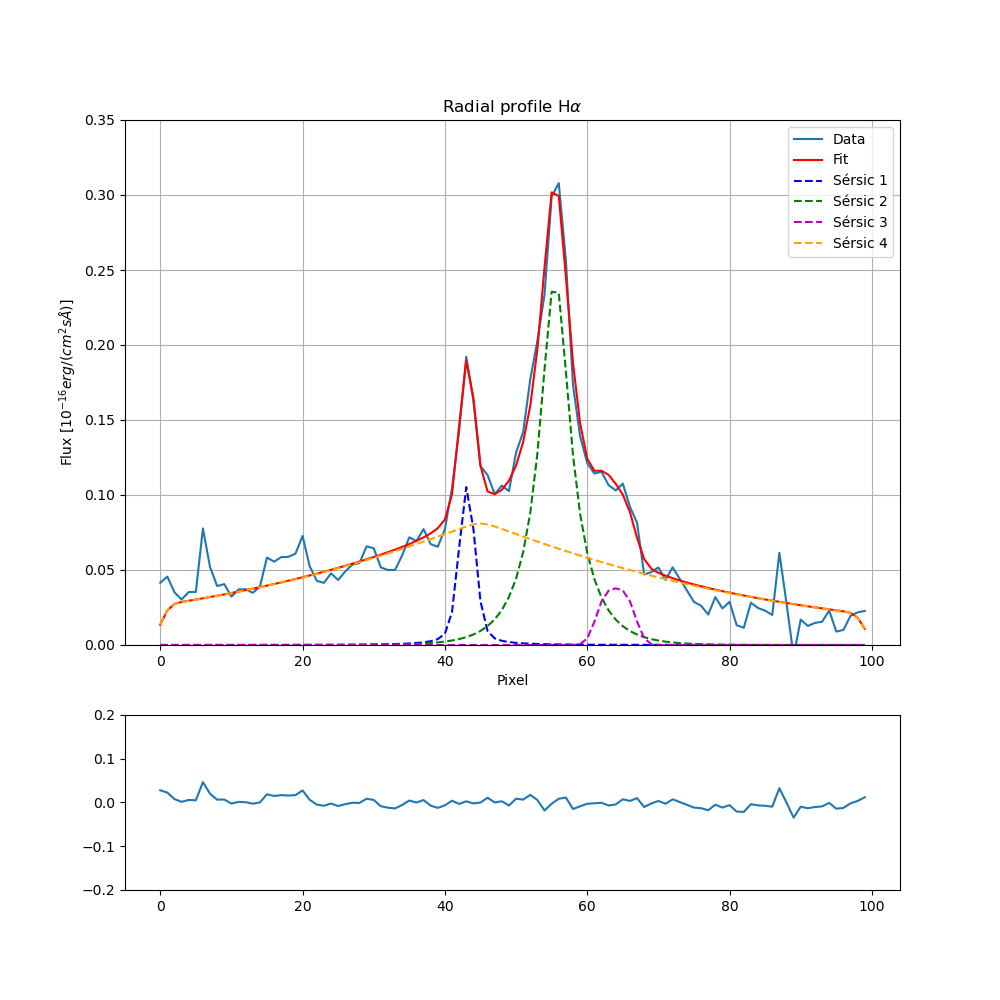

In [16]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [17]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA) #, bounds = bounds_list) #, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:11: RuntimeWarning: overflow encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=0.0013, r_e=21.2972, n=3.5592, x_0=43.1253
Sérsic 2: I_e=0.0316, r_e=9.0241, n=1.4290, x_0=55.4566
Sérsic 3: I_e=0.0266, r_e=2.5405, n=0.0659, x_0=64.5481
Sérsic 4: I_e=0.0205, r_e=58.1010, n=0.6185, x_0=28.5692
[4.11191851e-02 4.88468187e+02 3.02826521e+01 1.88201992e-03
 1.89629280e-02 5.46494343e+00 3.99857903e-01 9.43678768e-02
 4.83624103e-01 1.04765349e+01 1.39010115e+00 4.10525954e-01
 1.66152811e-02 3.70773771e+01 3.61747268e-01 1.50888742e+01]
0.047356142683305465


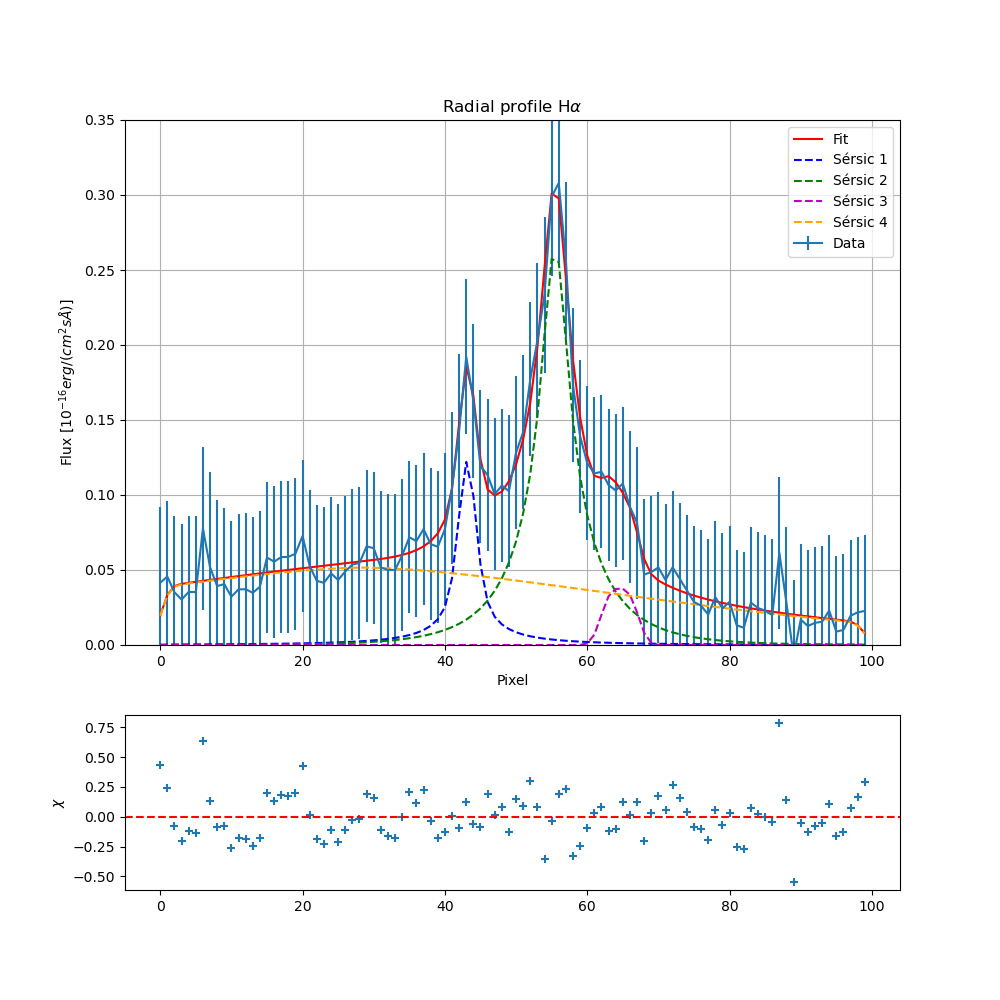

In [18]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [19]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 10),
    (0, 10),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),
 
    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (50, 150),
    (0.1, 10),
    (x_0_HA[3]-1, x_0_HA[3]+1),
    
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

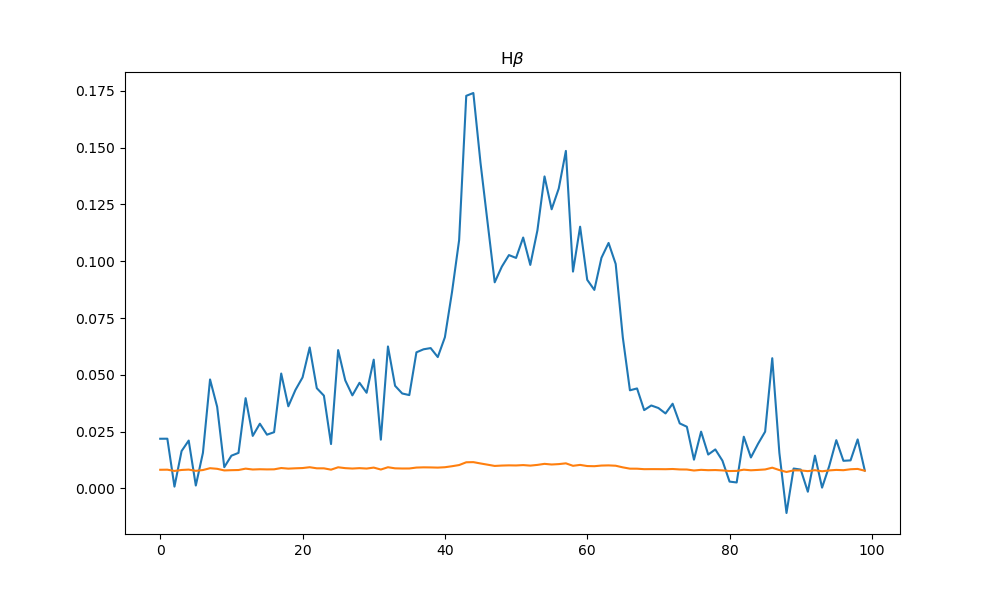

In [20]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [21]:
# Bounds:
bounds = bounds

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 35775.156533553934
differential_evolution step 2: f(x)= 24235.757570966864
differential_evolution step 3: f(x)= 6344.652143765701
differential_evolution step 4: f(x)= 1980.9400396404596
differential_evolution step 5: f(x)= 1980.9400396404596
differential_evolution step 6: f(x)= 1980.9400396404596
differential_evolution step 7: f(x)= 1980.9400396404596
differential_evolution step 8: f(x)= 1980.9400396404596
differential_evolution step 9: f(x)= 1980.9400396404596
differential_evolution step 10: f(x)= 876.2530127015407
differential_evolution step 11: f(x)= 876.2530127015407
differential_evolution step 12: f(x)= 784.682267532983
differential_evolution step 13: f(x)= 784.682267532983
differential_evolution step 14: f(x)= 316.0986601891004
differential_evolution step 15: f(x)= 316.0986601891004
differential_evolution step 16: f(x)= 316.0986601891004
differential_evolution step 17: f(x)= 264.0748301192441
differential_evolution step 18: f(x)= 264.074830119

Sérsic 1: I_e=0.0199, r_e=10.0000, n=1.1912, x_0=44.1253
Sérsic 2: I_e=1.9268, r_e=0.0188, n=7.4008, x_0=55.9360
Sérsic 3: I_e=0.0159, r_e=13.1009, n=0.9511, x_0=63.5481
Sérsic 4: I_e=0.0101, r_e=50.4792, n=0.7952, x_0=27.6242


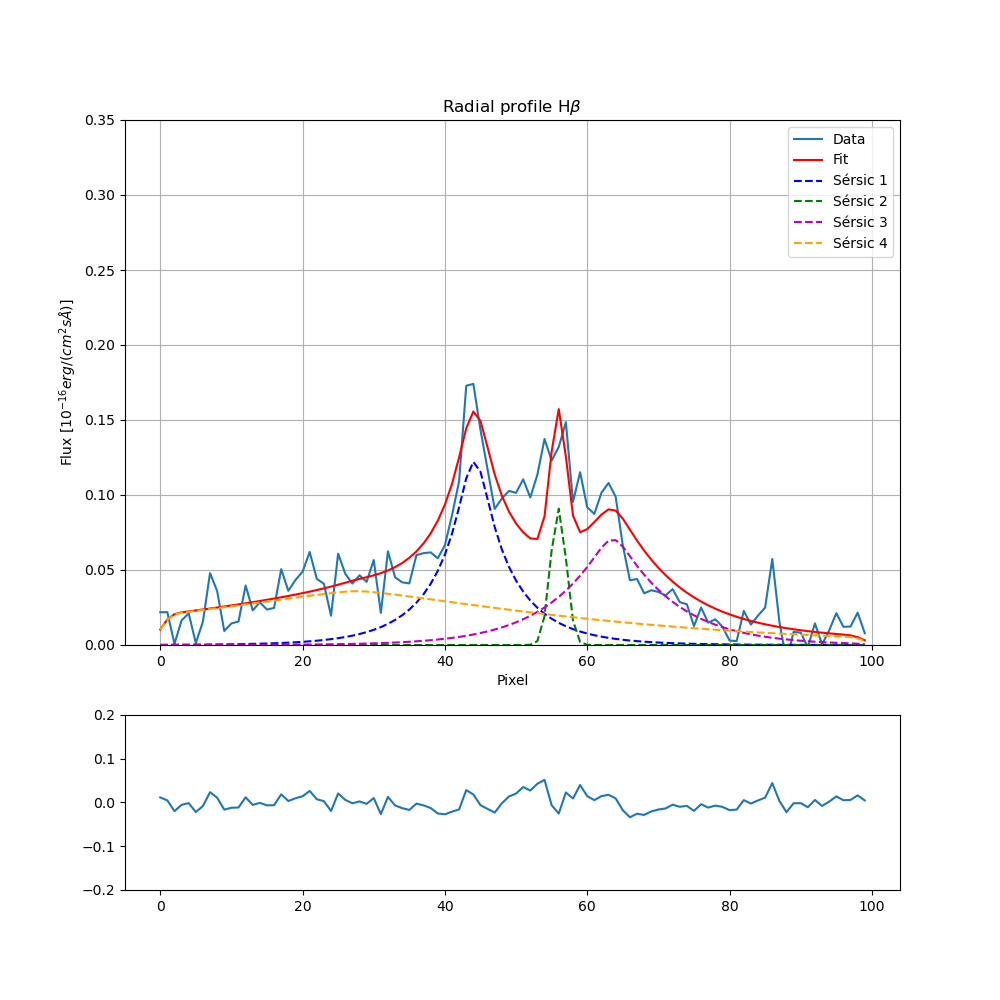

In [22]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [23]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0198, r_e=10.0000, n=1.1927, x_0=44.1253
Sérsic 2: I_e=1.5881, r_e=0.0206, n=9.9873, x_0=55.9362
Sérsic 3: I_e=0.0154, r_e=13.4250, n=0.9694, x_0=63.5481
Sérsic 4: I_e=0.0101, r_e=50.1161, n=0.7981, x_0=27.5716
[3.28122405e-02 1.89017581e+01 1.10506560e+00 4.18951151e-01
 1.41551936e+04 9.76017862e+01 3.29575490e+04 2.70494675e-01
 1.61894019e-02 1.43162635e+01 6.95598608e-01 1.35572000e+00
 1.79497459e-02 7.45782681e+01 8.21908632e-01 1.84353352e+01]
0.1370456789178483


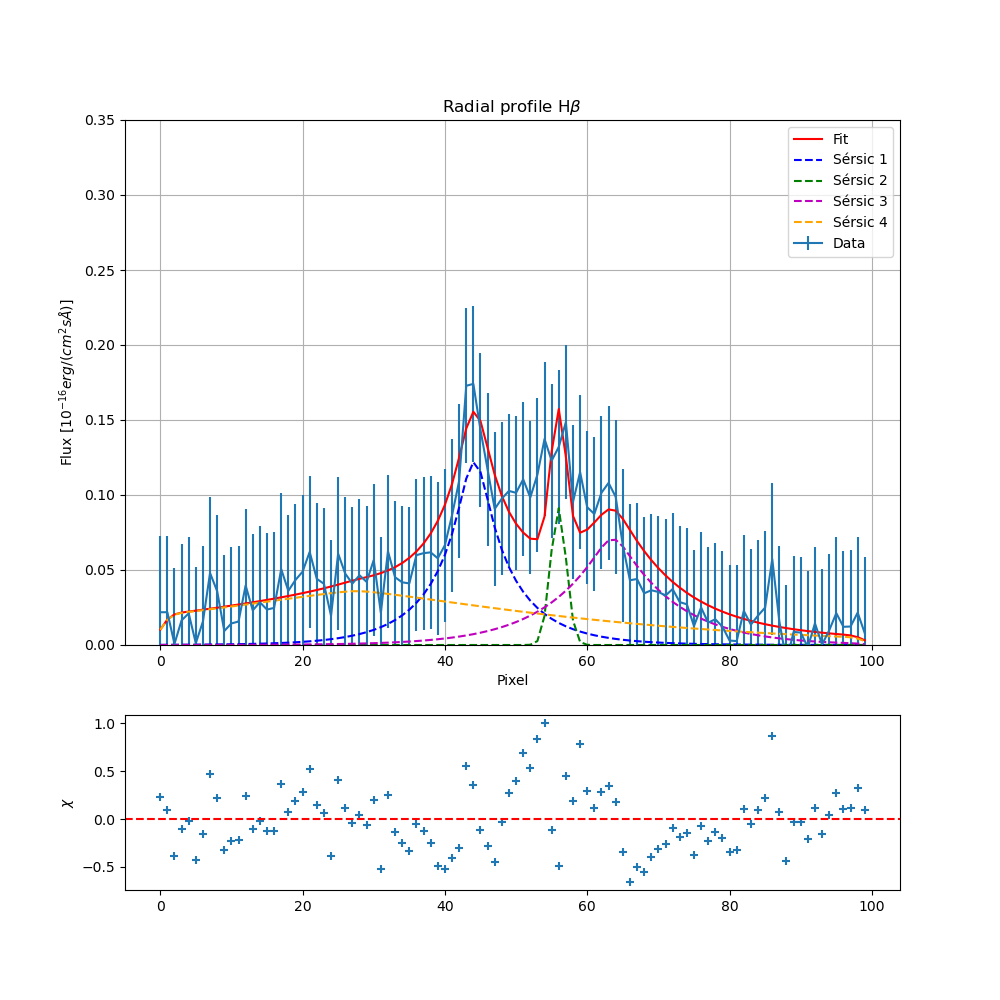

In [24]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

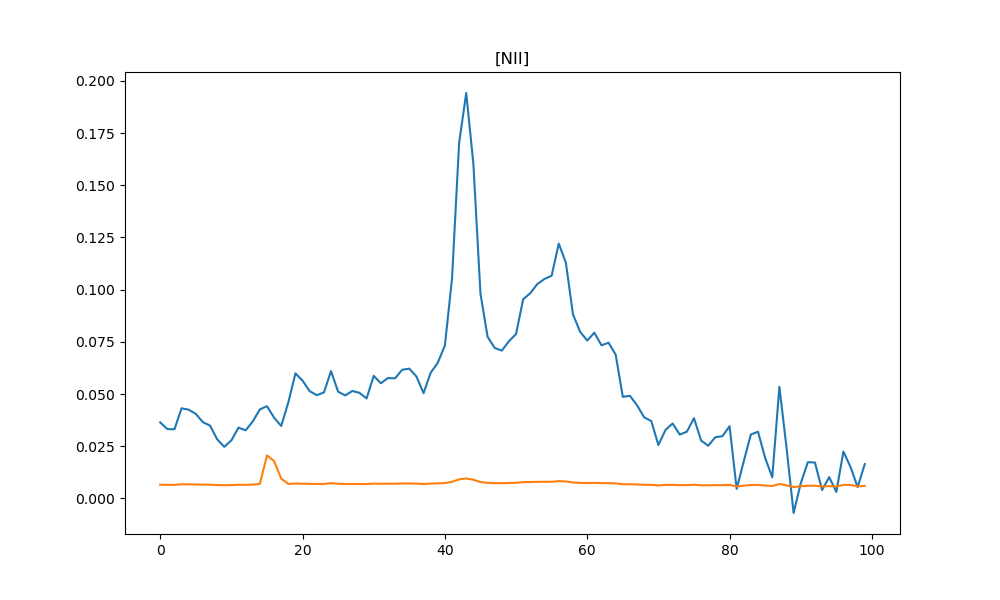

In [25]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [26]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 29527.235543976178
differential_evolution step 2: f(x)= 8733.219064483183
differential_evolution step 3: f(x)= 8733.219064483183
differential_evolution step 4: f(x)= 4029.8984427847454
differential_evolution step 5: f(x)= 4029.8984427847454
differential_evolution step 6: f(x)= 3570.7545722929785
differential_evolution step 7: f(x)= 3499.4589552794782
differential_evolution step 8: f(x)= 259.43328581083676
differential_evolution step 9: f(x)= 259.43328581083676
differential_evolution step 10: f(x)= 259.43328581083676
differential_evolution step 11: f(x)= 259.43328581083676
differential_evolution step 12: f(x)= 259.43328581083676
differential_evolution step 13: f(x)= 259.43328581083676
differential_evolution step 14: f(x)= 199.7358132949764
differential_evolution step 15: f(x)= 199.7358132949764
differential_evolution step 16: f(x)= 199.7358132949764
differential_evolution step 17: f(x)= 199.7358132949764
differential_evolution step 18: f(x)= 199.7358

Sérsic 1: I_e=2.2435, r_e=0.0336, n=0.6929, x_0=42.8851
Sérsic 2: I_e=0.8425, r_e=0.0683, n=0.1627, x_0=55.9901
Sérsic 3: I_e=0.0239, r_e=15.5299, n=0.2687, x_0=63.5481
Sérsic 4: I_e=0.0172, r_e=50.0000, n=0.7862, x_0=29.5692


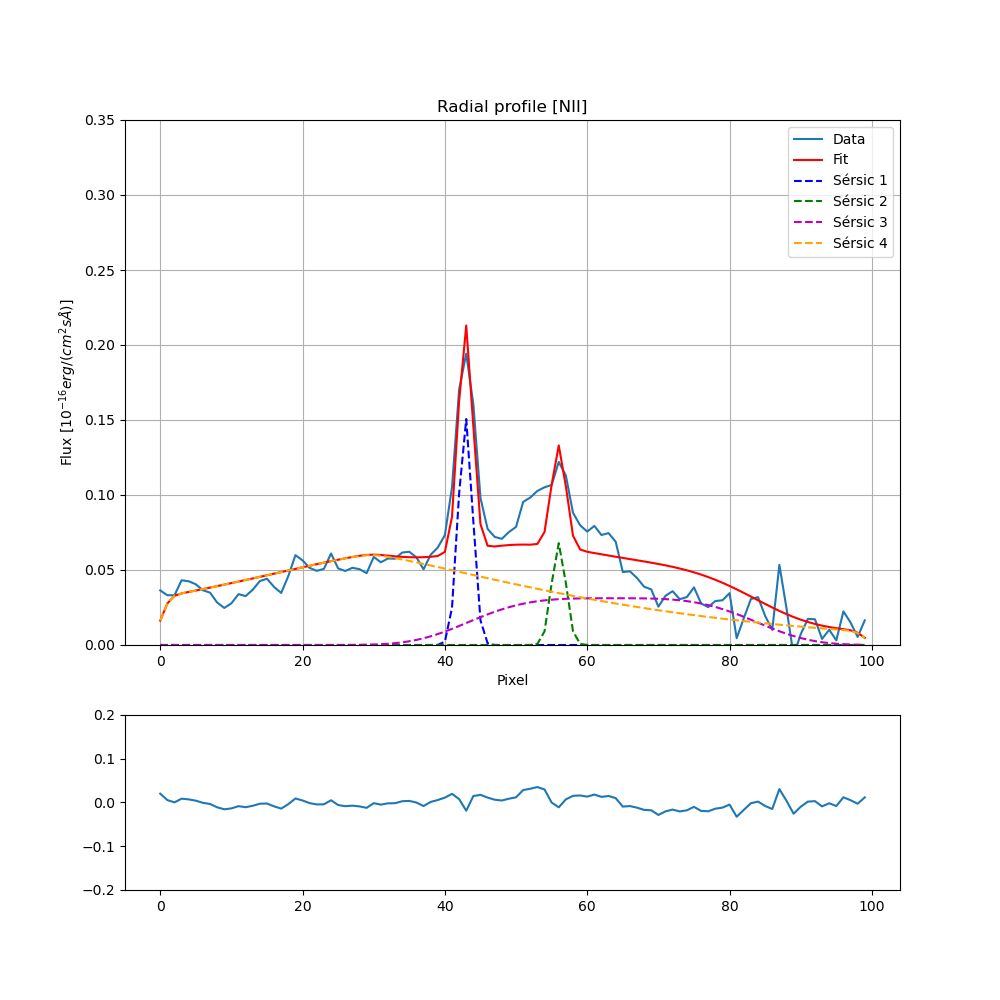

In [27]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [28]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0764, r_e=1.0796, n=0.7764, x_0=42.8653
Sérsic 2: I_e=0.0190, r_e=10.0000, n=0.8856, x_0=55.5100
Sérsic 3: I_e=0.0051, r_e=21.9608, n=0.1000, x_0=63.5481
Sérsic 4: I_e=0.0145, r_e=58.1502, n=0.8333, x_0=29.5692
[9.20698883e-02 5.00512433e-01 1.07606498e+00 8.38036624e-02
 7.72563666e-03 4.87526552e+00 2.83110586e-01 3.77184158e-01
 9.78046790e-03 2.51311724e+01 3.19272331e-01 6.63123383e+00
 7.98036042e-03 2.61536546e+01 2.90795372e-01 4.88156059e+00]
0.02917052095867745


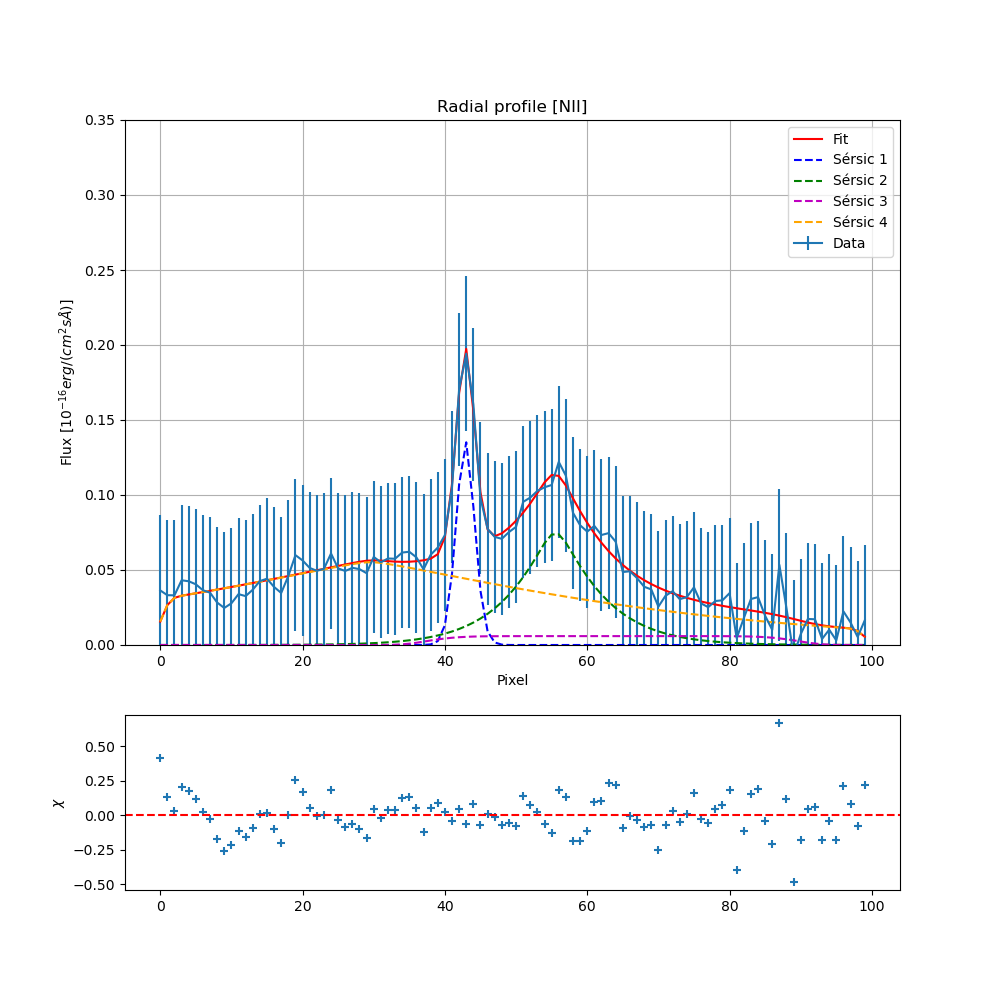

In [29]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

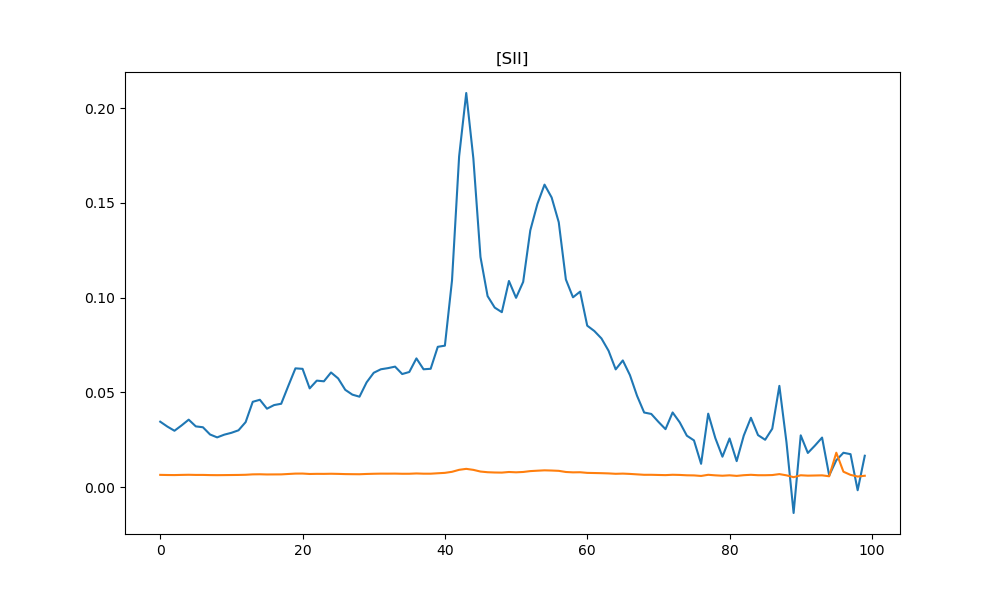

In [31]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [32]:
# Bounds:
bounds = bounds
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 19381.774836172568
differential_evolution step 2: f(x)= 3935.132177385267
differential_evolution step 3: f(x)= 3935.132177385267
differential_evolution step 4: f(x)= 3935.132177385267
differential_evolution step 5: f(x)= 3935.132177385267
differential_evolution step 6: f(x)= 3935.132177385267
differential_evolution step 7: f(x)= 3935.132177385267
differential_evolution step 8: f(x)= 1739.4142281965956
differential_evolution step 9: f(x)= 1739.4142281965956
differential_evolution step 10: f(x)= 1283.8786652382776
differential_evolution step 11: f(x)= 953.7517056884873
differential_evolution step 12: f(x)= 953.7517056884873
differential_evolution step 13: f(x)= 230.11924111400552
differential_evolution step 14: f(x)= 230.11924111400552
differential_evolution step 15: f(x)= 230.11924111400552
differential_evolution step 16: f(x)= 99.6353581485358
differential_evolution step 17: f(x)= 99.6353581485358
differential_evolution step 18: f(x)= 99.63535814853

Sérsic 1: I_e=0.0185, r_e=2.5429, n=1.9140, x_0=42.9788
Sérsic 2: I_e=0.0243, r_e=9.9997, n=1.0007, x_0=54.4566
Sérsic 3: I_e=0.0076, r_e=40.4771, n=0.1000, x_0=63.5487
Sérsic 4: I_e=0.0156, r_e=50.0056, n=0.7283, x_0=29.2119


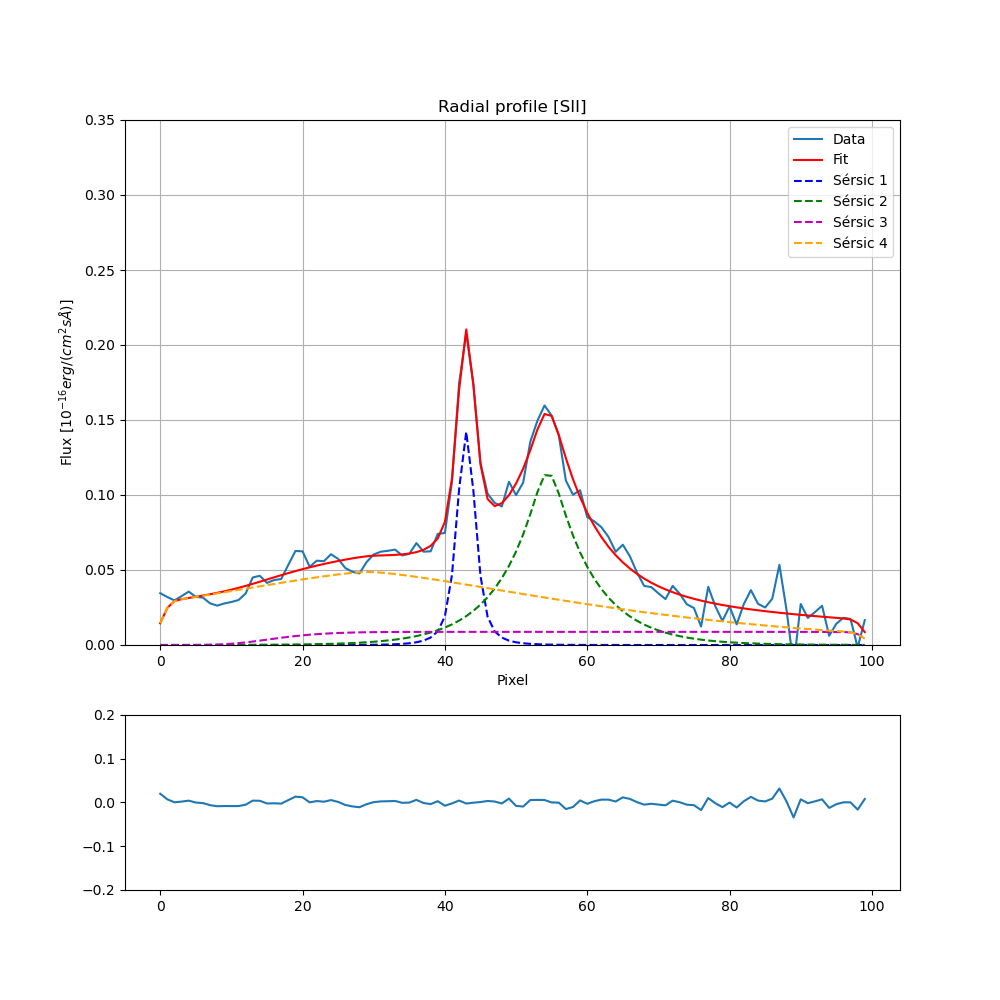

In [33]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [34]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0179, r_e=2.5966, n=1.9396, x_0=42.9792
Sérsic 2: I_e=0.0243, r_e=10.0000, n=1.0006, x_0=54.4566
Sérsic 3: I_e=0.0076, r_e=40.4542, n=0.1000, x_0=63.5481
Sérsic 4: I_e=0.0156, r_e=50.0000, n=0.7270, x_0=29.1033
[4.38812421e-02 4.20010073e+00 2.02783960e+00 8.33575692e-02
 7.42511770e-03 4.37513259e+00 2.32449920e-01 2.44786940e-01
 2.32373300e-02 6.96470853e+01 3.04667655e-01 5.94134342e+01
 2.21091986e-02 7.61217626e+01 8.93210621e-01 9.30413727e+00]
0.03082095544120517


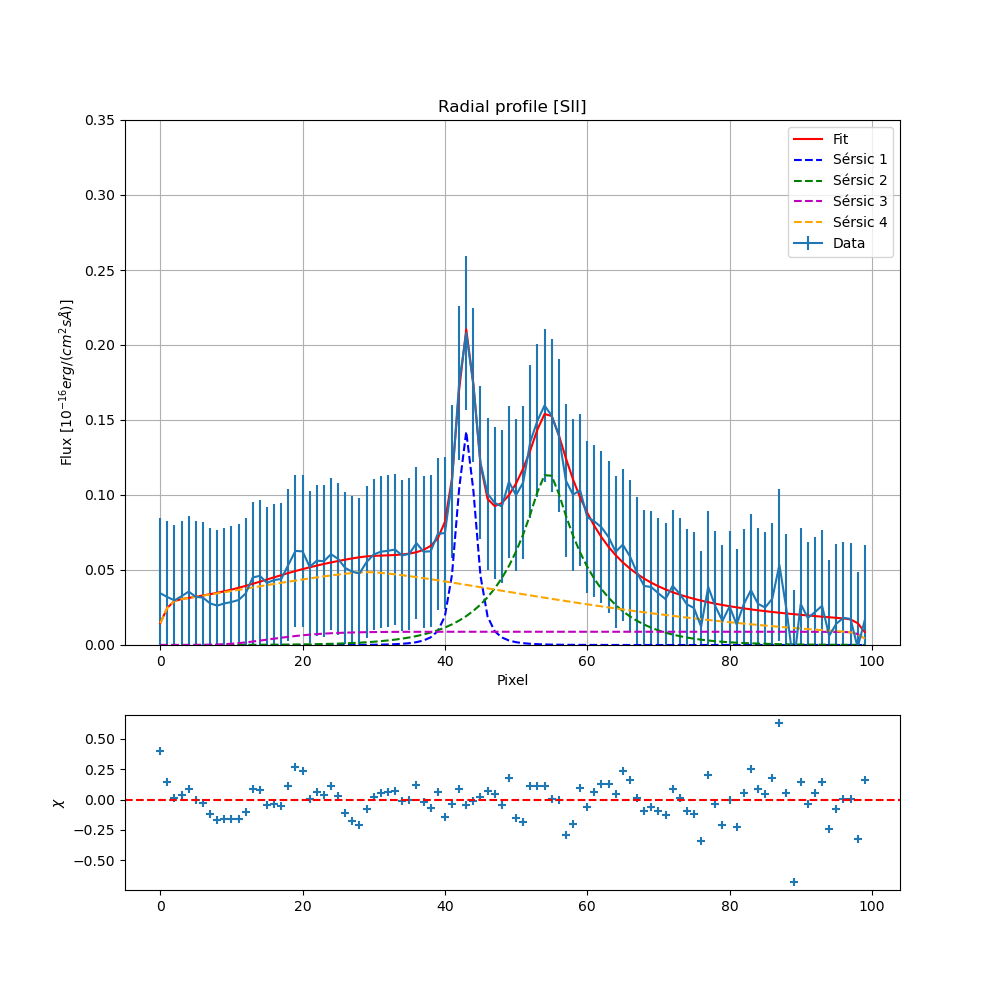

In [35]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

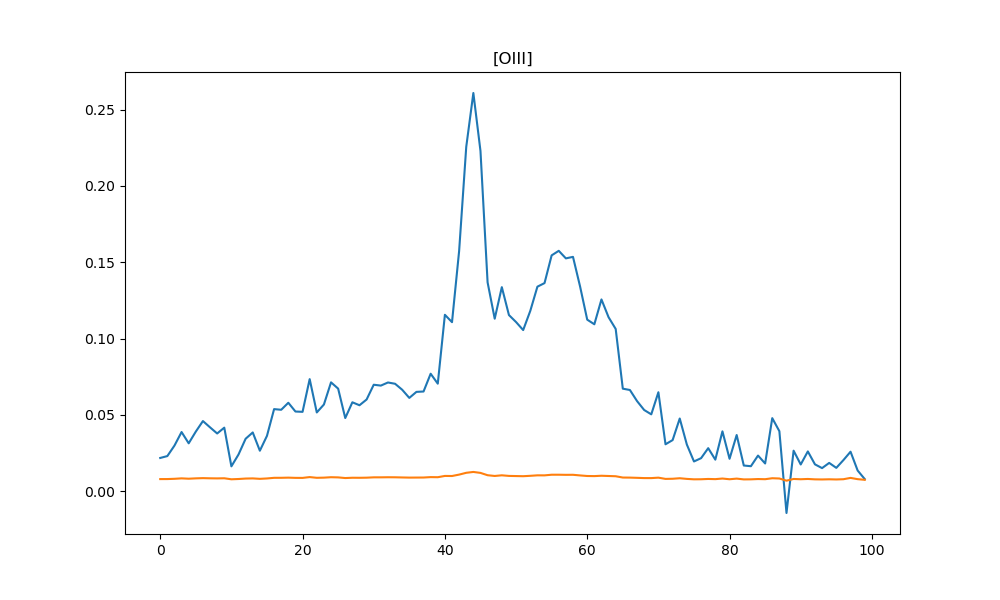

In [36]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [37]:
# Bounds:
bounds =[
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 5),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1, x_0_HA[0]+1),   # x_0: circa la posizione di Halpha

    (0, 1),
    (0, 5),
    (0.1, 10),
    (x_0_HA[1]-1, x_0_HA[1]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1, x_0_HA[2]+1),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 615.4218744466526
differential_evolution step 2: f(x)= 615.4218744466526
differential_evolution step 3: f(x)= 346.3743431552353
differential_evolution step 4: f(x)= 346.3743431552353
differential_evolution step 5: f(x)= 346.3743431552353
differential_evolution step 6: f(x)= 346.3743431552353
differential_evolution step 7: f(x)= 346.3743431552353
differential_evolution step 8: f(x)= 346.3743431552353
differential_evolution step 9: f(x)= 26.853276616453222
differential_evolution step 10: f(x)= 26.853276616453222
differential_evolution step 11: f(x)= 26.853276616453222
differential_evolution step 12: f(x)= 26.853276616453222
differential_evolution step 13: f(x)= 26.853276616453222
differential_evolution step 14: f(x)= 26.853276616453222
differential_evolution step 15: f(x)= 11.074177824838172
differential_evolution step 16: f(x)= 11.074177824838172
differential_evolution step 17: f(x)= 11.074177824838172
differential_evolution step 18: f(x)= 1.32178525

Sérsic 1: I_e=0.0165, r_e=4.9892, n=1.9681, x_0=43.8927
Sérsic 2: I_e=0.2372, r_e=0.0548, n=5.7332, x_0=55.9871
Sérsic 3: I_e=0.0195, r_e=23.4412, n=0.8839, x_0=63.5481
Sérsic 4: I_e=0.0420, r_e=28.1934, n=0.1000, x_0=29.7537


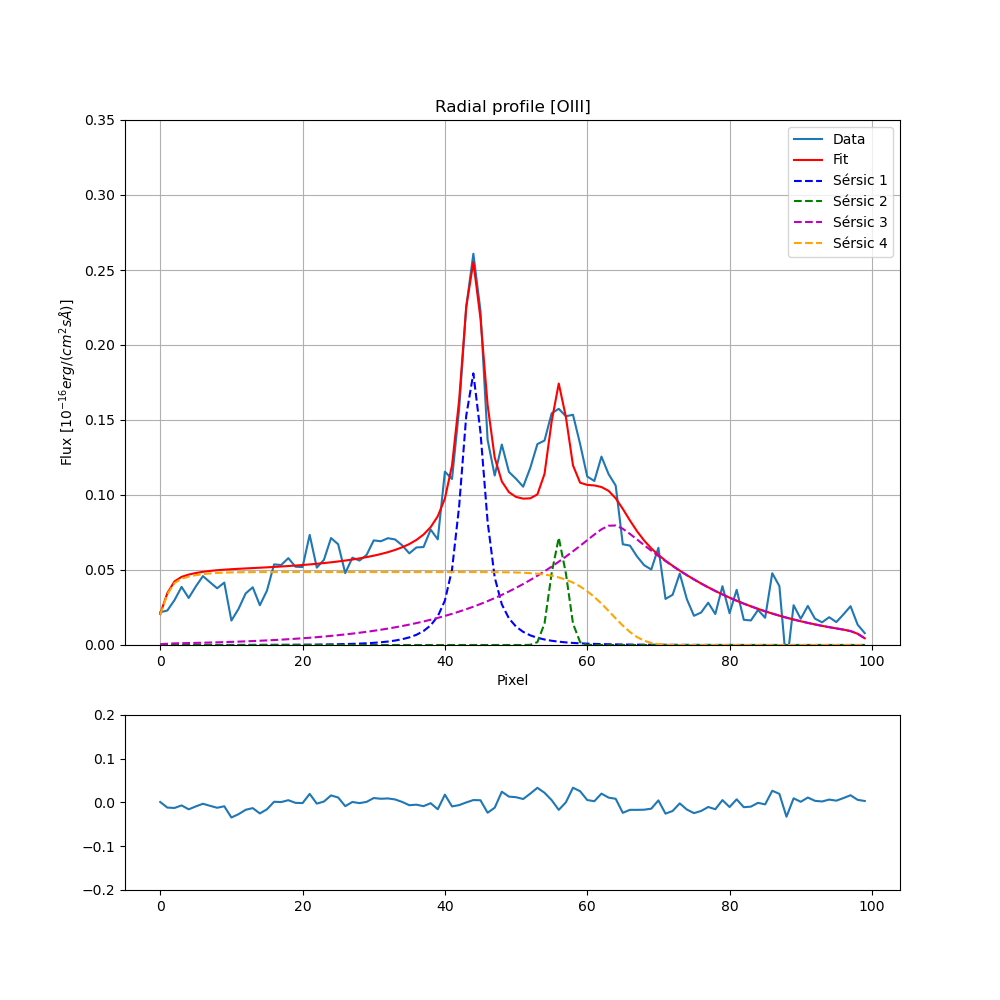

In [38]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [39]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0165, r_e=4.9892, n=1.9681, x_0=43.8927
Sérsic 2: I_e=0.2372, r_e=0.0548, n=5.7332, x_0=55.9871
Sérsic 3: I_e=0.0195, r_e=23.4412, n=0.8839, x_0=63.5481
Sérsic 4: I_e=0.0420, r_e=28.1934, n=0.1000, x_0=29.7537
[6.31661261e-02 1.25346536e+01 4.93228923e+00 3.65766404e-02
 2.34585613e+02 5.16759330e+01 9.83495584e+03 4.75357187e-01
 1.45326560e-02 1.14123515e+01 7.42163341e-01 4.30330006e+00
 1.61816156e-02 1.29524795e+01 1.45455869e-01 7.50575477e+00]
0.0929086291093231


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


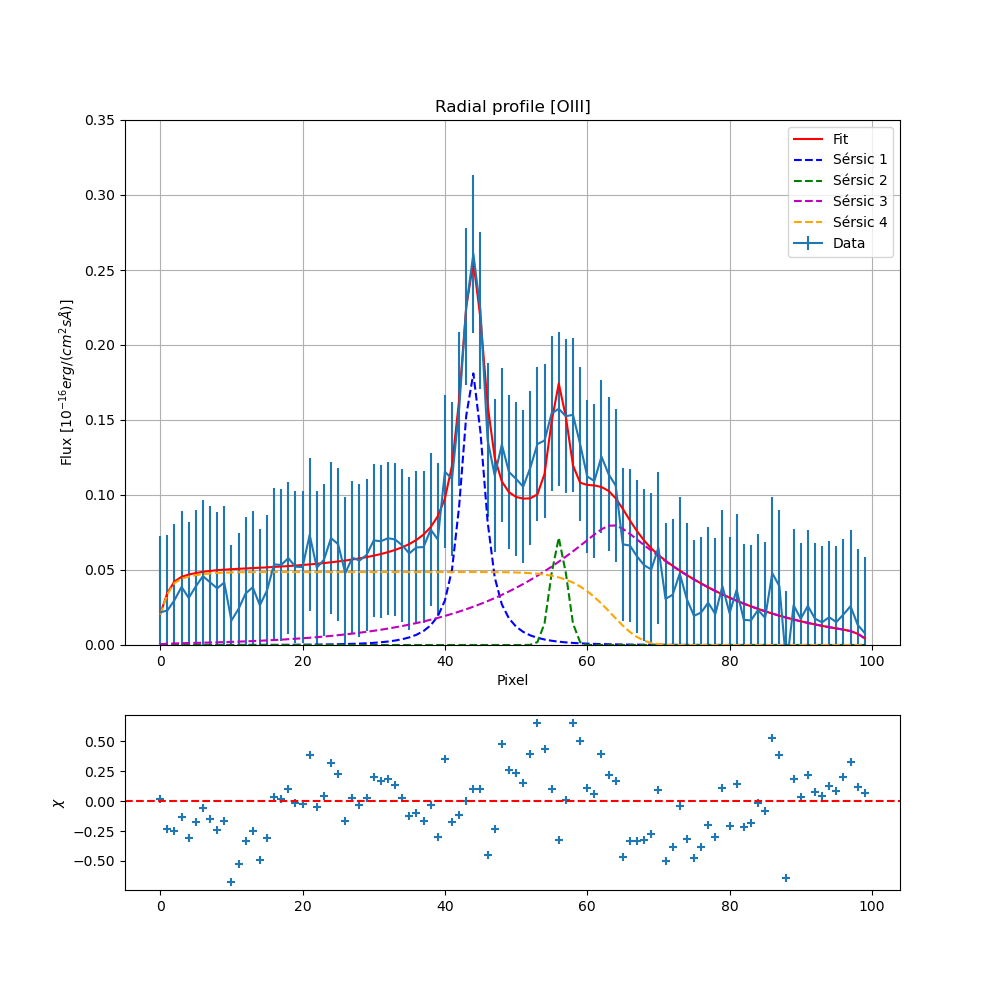

In [40]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [41]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

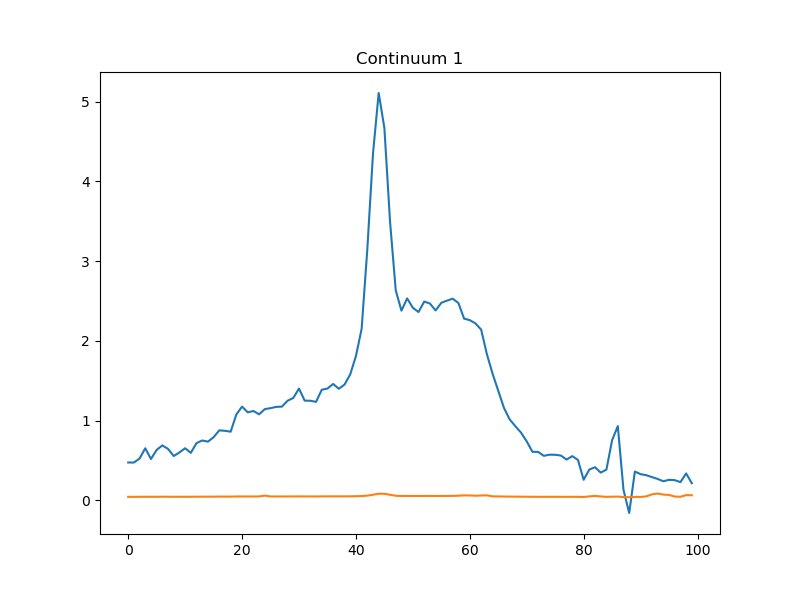

In [44]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [45]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 56646.92974066109
differential_evolution step 2: f(x)= 45699.99390547848
differential_evolution step 3: f(x)= 45699.99390547848
differential_evolution step 4: f(x)= 45699.99390547848
differential_evolution step 5: f(x)= 25226.872520063913
differential_evolution step 6: f(x)= 25226.872520063913
differential_evolution step 7: f(x)= 25226.872520063913
differential_evolution step 8: f(x)= 10819.5793361049
differential_evolution step 9: f(x)= 10819.5793361049
differential_evolution step 10: f(x)= 4535.2426588812295
differential_evolution step 11: f(x)= 4535.2426588812295
differential_evolution step 12: f(x)= 4535.2426588812295
differential_evolution step 13: f(x)= 4535.2426588812295
differential_evolution step 14: f(x)= 2967.893637375755
differential_evolution step 15: f(x)= 2967.893637375755
differential_evolution step 16: f(x)= 2967.893637375755
differential_evolution step 17: f(x)= 2477.614993320925
differential_evolution step 18: f(x)= 2477.614993320

In [46]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.7553, r_e=1.1689, n=0.3395, x_0=44.0000
Sérsic 2: I_e=0.7060, r_e=5.6101, n=0.3306, x_0=55.1892
Sérsic 3: I_e=0.2105, r_e=2.8410, n=0.5894, x_0=62.0000
Sérsic 4: I_e=0.3616, r_e=50.0000, n=1.0273, x_0=45.0000


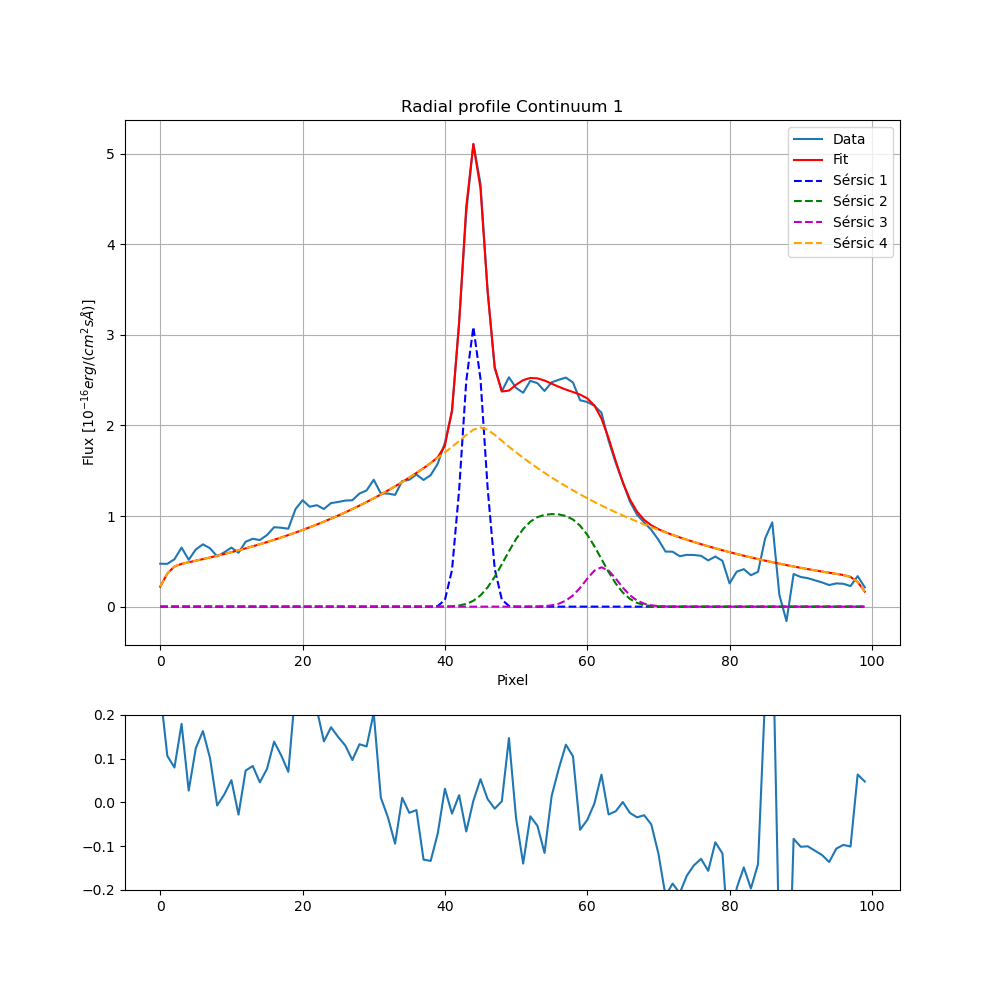

In [47]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [48]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=3.2199, r_e=1.1539, n=0.1812, x_0=44.0000
Sérsic 2: I_e=0.6927, r_e=5.5116, n=0.3399, x_0=55.3280
Sérsic 3: I_e=0.2431, r_e=2.6786, n=0.5176, x_0=62.0000
Sérsic 4: I_e=0.3486, r_e=50.0000, n=1.0694, x_0=45.0000
[ 4.31174314  1.64565452  2.20210262  0.25972933  4.93215089 35.69650862
  3.46292769 68.59882334 10.6125716  17.42698196  1.33629451  4.5369286
  0.13127836 13.92444053  0.27708599  1.08202938]
4.847404846003071


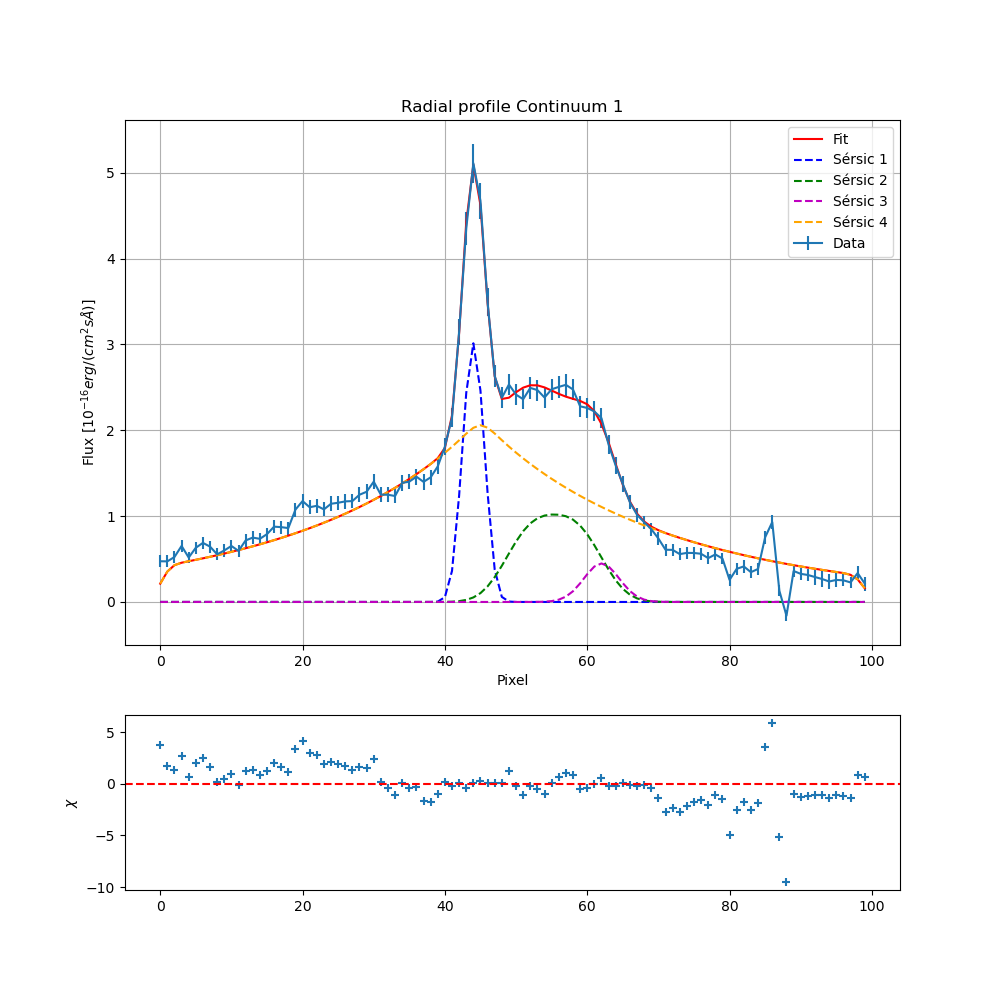

In [49]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

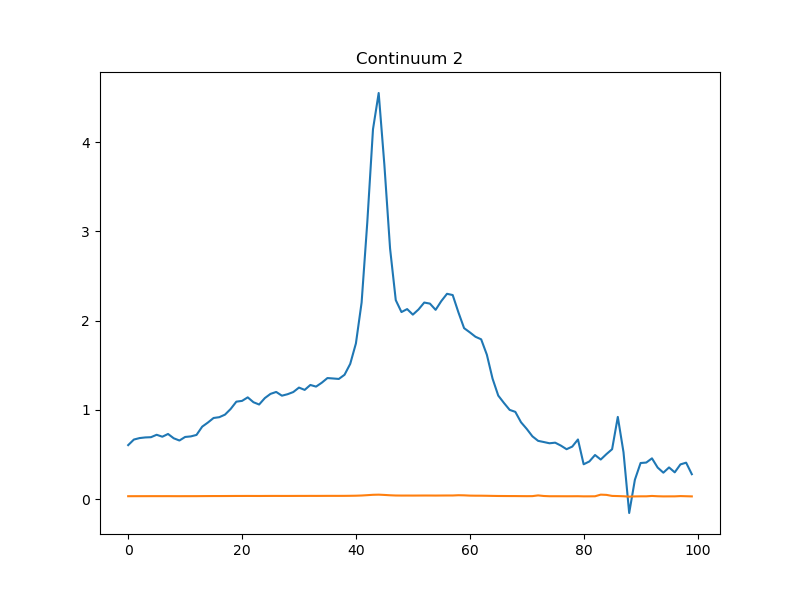

In [50]:
mask_continuum_2 = (wv > 5100)*(wv < 5400)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [51]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 279344.9579215224
differential_evolution step 2: f(x)= 28782.857080679067
differential_evolution step 3: f(x)= 28782.857080679067
differential_evolution step 4: f(x)= 20377.83677411812
differential_evolution step 5: f(x)= 9843.108765595145
differential_evolution step 6: f(x)= 3147.5211832917253
differential_evolution step 7: f(x)= 3147.5211832917253
differential_evolution step 8: f(x)= 3147.5211832917253
differential_evolution step 9: f(x)= 3147.5211832917253
differential_evolution step 10: f(x)= 3147.5211832917253
differential_evolution step 11: f(x)= 2126.1326870707176
differential_evolution step 12: f(x)= 2126.1326870707176
differential_evolution step 13: f(x)= 2126.1326870707176
differential_evolution step 14: f(x)= 2126.1326870707176
differential_evolution step 15: f(x)= 1340.1902676988816
differential_evolution step 16: f(x)= 1340.1902676988816
differential_evolution step 17: f(x)= 656.0663974014695
differential_evolution step 18: f(x)= 477.56

Sérsic 1: I_e=1.3388, r_e=1.5921, n=0.7516, x_0=43.7398
Sérsic 2: I_e=0.5517, r_e=5.4829, n=0.3809, x_0=55.4113
Sérsic 3: I_e=0.0196, r_e=0.7297, n=3.5852, x_0=62.3113
Sérsic 4: I_e=0.4145, r_e=50.0000, n=0.8640, x_0=45.0000


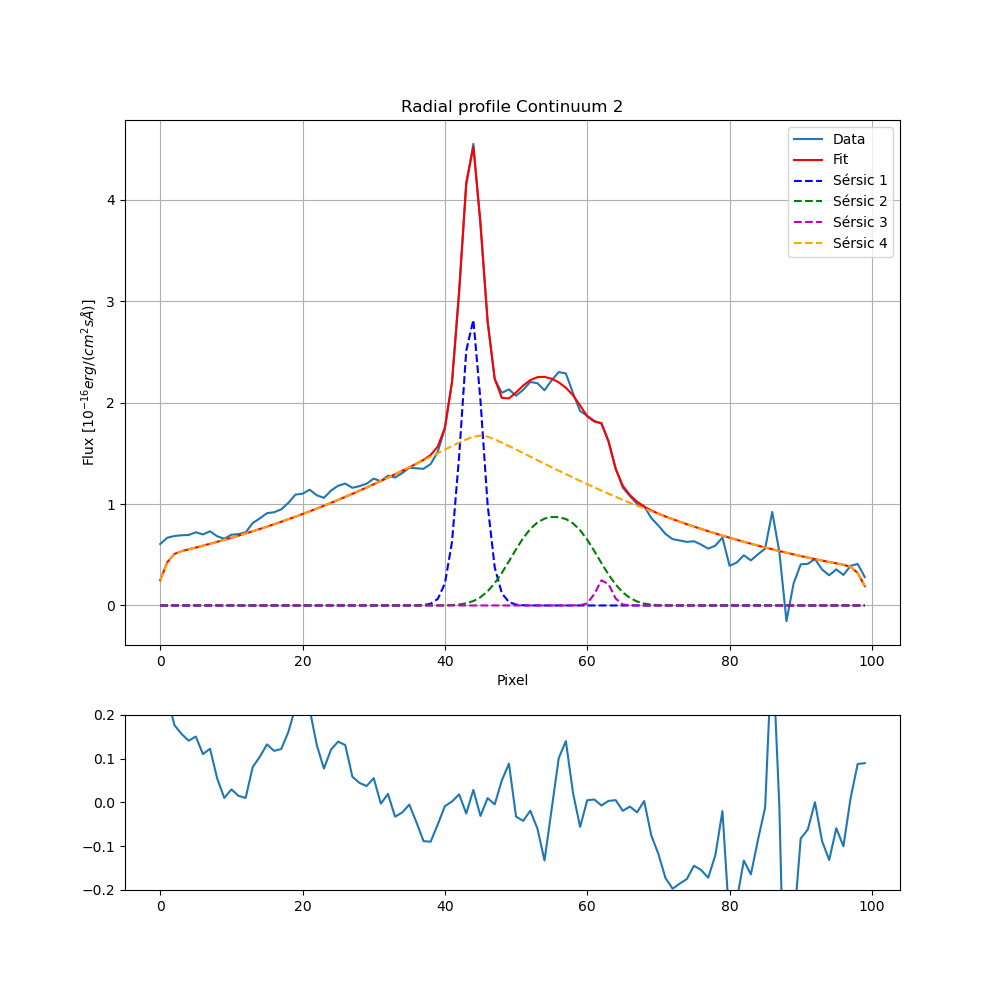

In [52]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [53]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=1.5385, r_e=1.4716, n=0.6315, x_0=43.7409
Sérsic 2: I_e=0.5465, r_e=5.4565, n=0.3756, x_0=55.5180
Sérsic 3: I_e=0.0213, r_e=0.6948, n=3.5573, x_0=62.3113
Sérsic 4: I_e=0.4010, r_e=50.0000, n=0.8994, x_0=45.0000
[1.40283248e+00 6.29069607e-01 7.77227914e-01 2.01136311e-01
 2.01348103e-01 4.86070873e+00 2.61569955e-01 5.56465152e+00
 3.60541580e+01 6.24285419e+02 6.82404166e+03 2.68475435e-01
 1.44490208e-01 1.35145910e+01 2.51342789e-01 1.31257610e+00]
5.170251537009251


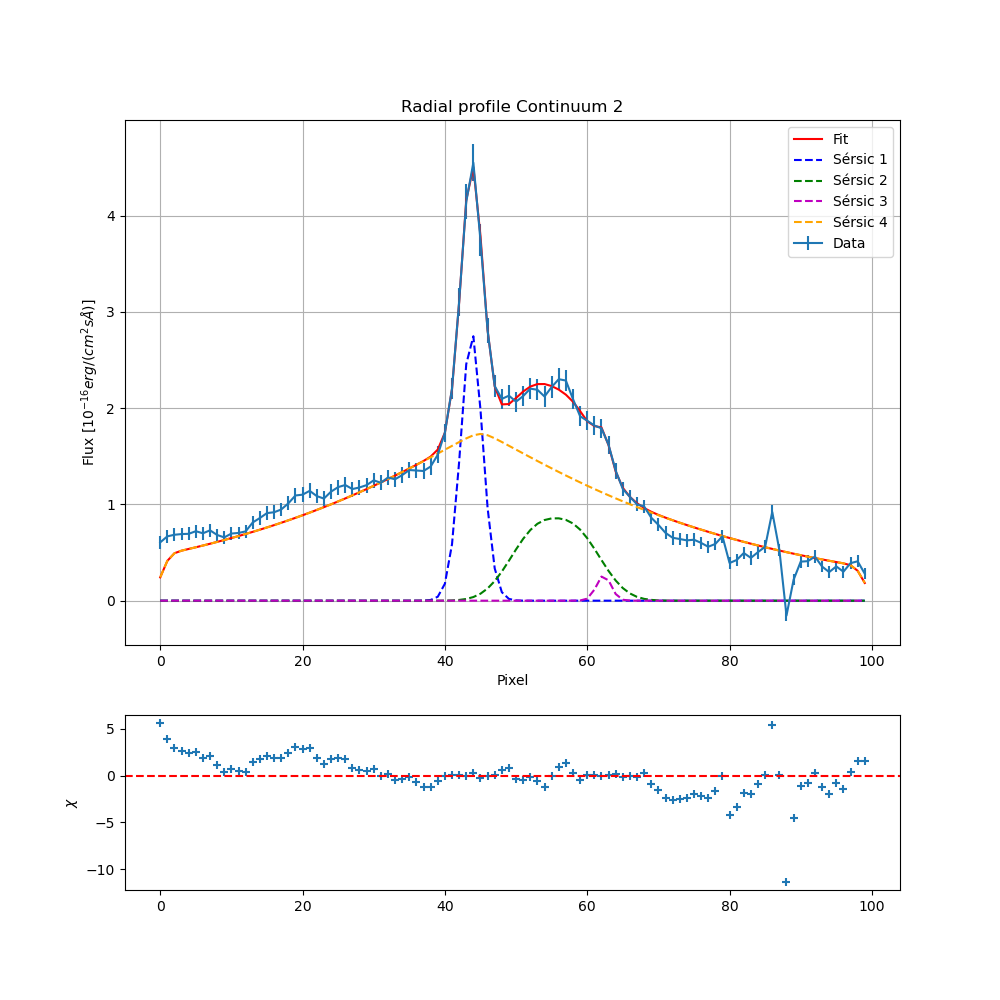

In [54]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

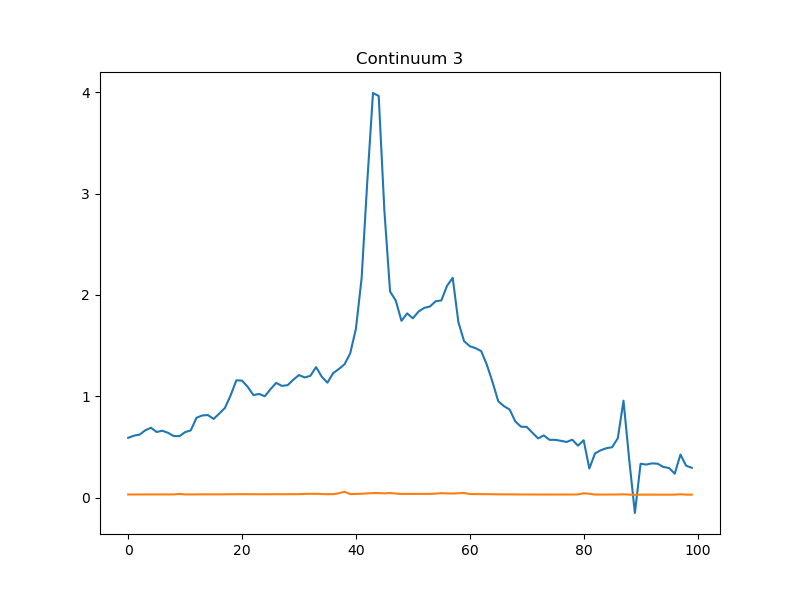

In [55]:
mask_continuum_3 = (wv > 5910)*(wv < 6210)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [56]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 122536.82578612755
differential_evolution step 2: f(x)= 29517.201903352856
differential_evolution step 3: f(x)= 15321.917043679705
differential_evolution step 4: f(x)= 15321.917043679705
differential_evolution step 5: f(x)= 15321.917043679705
differential_evolution step 6: f(x)= 14938.202160346833
differential_evolution step 7: f(x)= 14938.202160346833
differential_evolution step 8: f(x)= 8462.064393200915
differential_evolution step 9: f(x)= 5590.028784232843
differential_evolution step 10: f(x)= 1246.28286169738
differential_evolution step 11: f(x)= 1246.28286169738
differential_evolution step 12: f(x)= 1116.0946037045055
differential_evolution step 13: f(x)= 1116.0946037045055
differential_evolution step 14: f(x)= 1116.0946037045055
differential_evolution step 15: f(x)= 434.6691887185235
differential_evolution step 16: f(x)= 434.6691887185235
differential_evolution step 17: f(x)= 434.6691887185235
differential_evolution step 18: f(x)= 434.6691887

Sérsic 1: I_e=0.9555, r_e=1.4642, n=1.0397, x_0=43.3423
Sérsic 2: I_e=0.3552, r_e=4.6157, n=0.5616, x_0=55.4893
Sérsic 3: I_e=0.0001, r_e=0.8628, n=9.3429, x_0=62.1628
Sérsic 4: I_e=0.3833, r_e=50.0203, n=0.8840, x_0=45.0000


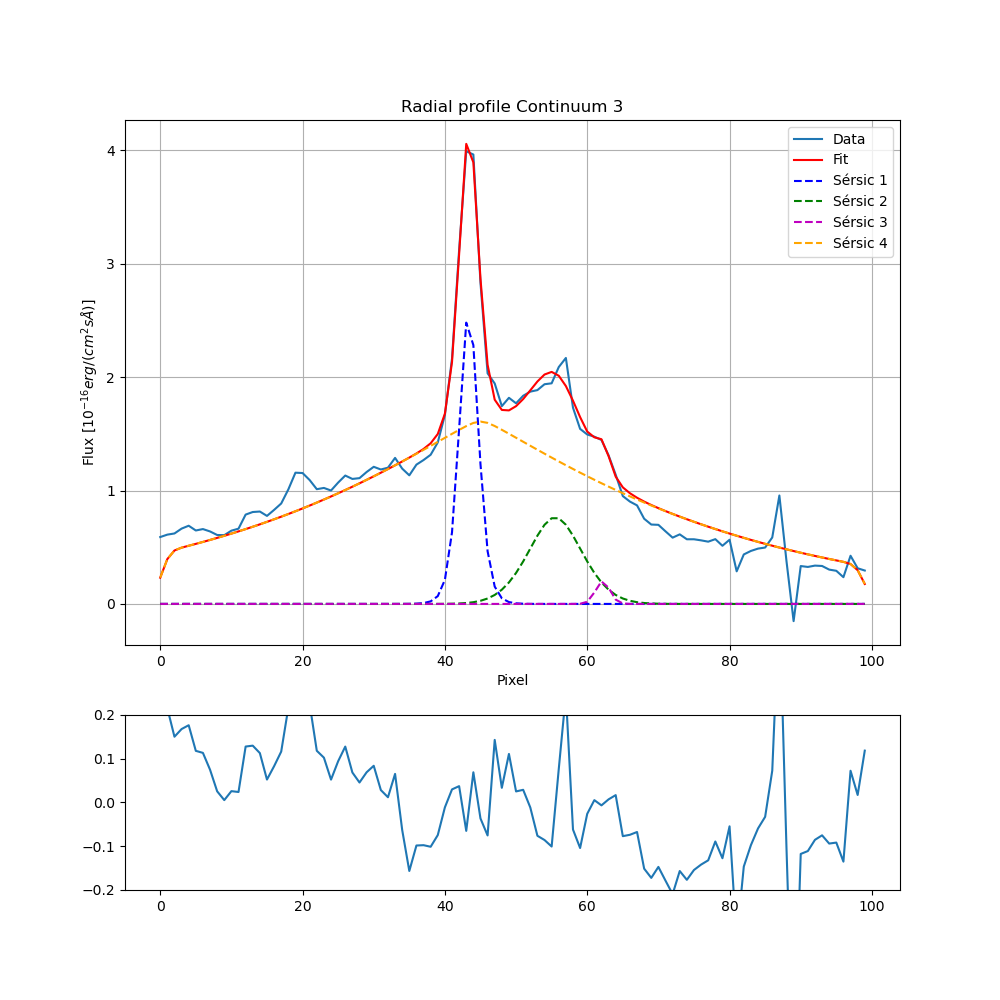

In [57]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [58]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_2324\1756458187.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.7628, r_e=2.0882, n=1.1787, x_0=43.3294
Sérsic 2: I_e=0.5072, r_e=6.8745, n=0.5315, x_0=54.8621
Sérsic 3: I_e=0.0001, r_e=0.7795, n=9.3321, x_0=62.1628
Sérsic 4: I_e=0.3817, r_e=51.7045, n=0.7531, x_0=36.8006
[7.44055763e-01 1.26364942e+00 8.14665570e-01 1.24912579e-01
 1.24532602e-01 2.53797225e+00 1.68617805e-01 1.81343763e+00
 3.27139196e+01 1.21757335e+05 2.44275290e+06 6.85807535e+01
 1.08273285e-01 1.16441214e+01 1.50981052e-01 2.43759068e+00]
3.186539623014088


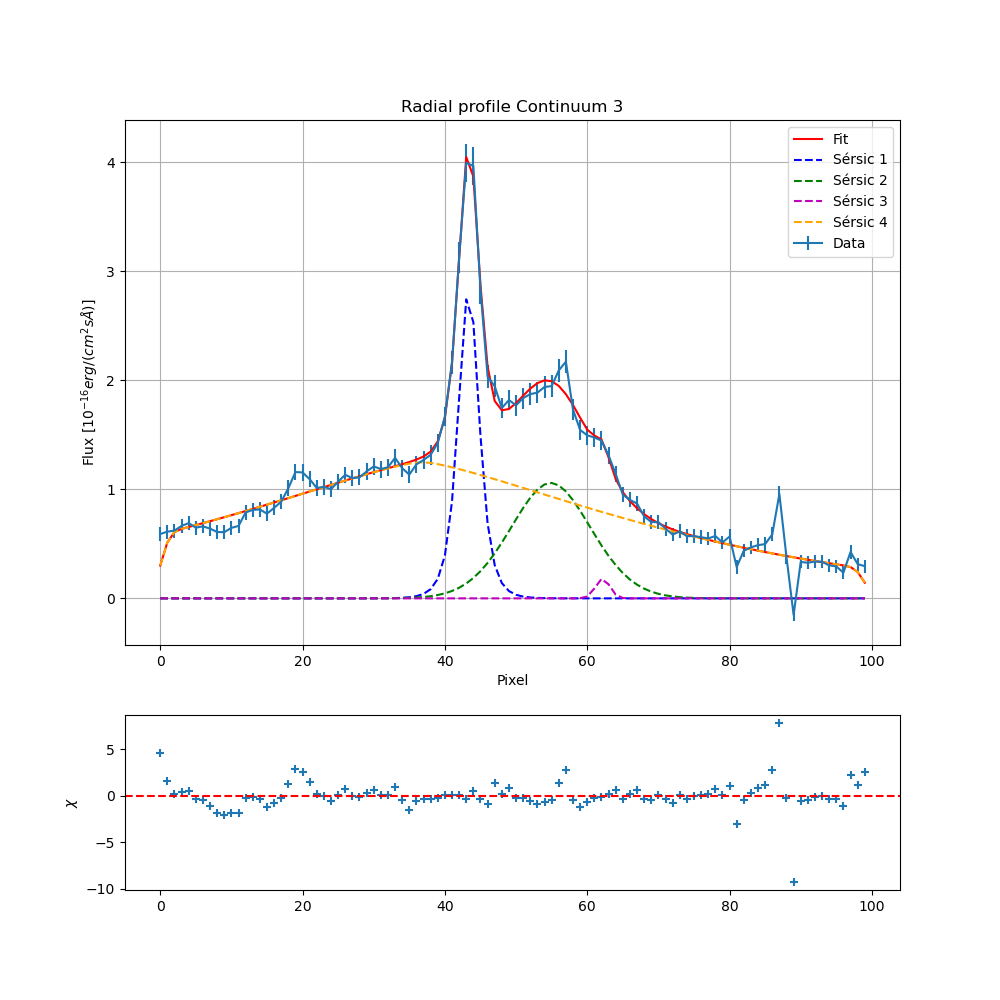

In [59]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [60]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)